In [393]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [394]:
X_train_df = pd.read_csv('./X_train.csv', skiprows=1, header=None)
y_train_df = pd.read_csv('./y_train.csv', skiprows=1, header=None)
X_test_df = pd.read_csv('./X_test.csv', skiprows=1, header=None)

X_train = X_train_df.values[:, 1:]
y_train = y_train_df.values[:, 1:]
X_test = X_test_df.values[:, 1:]

print(X_train.shape, y_train.shape, X_test.shape)


(1212, 832) (1212, 1) (776, 832)


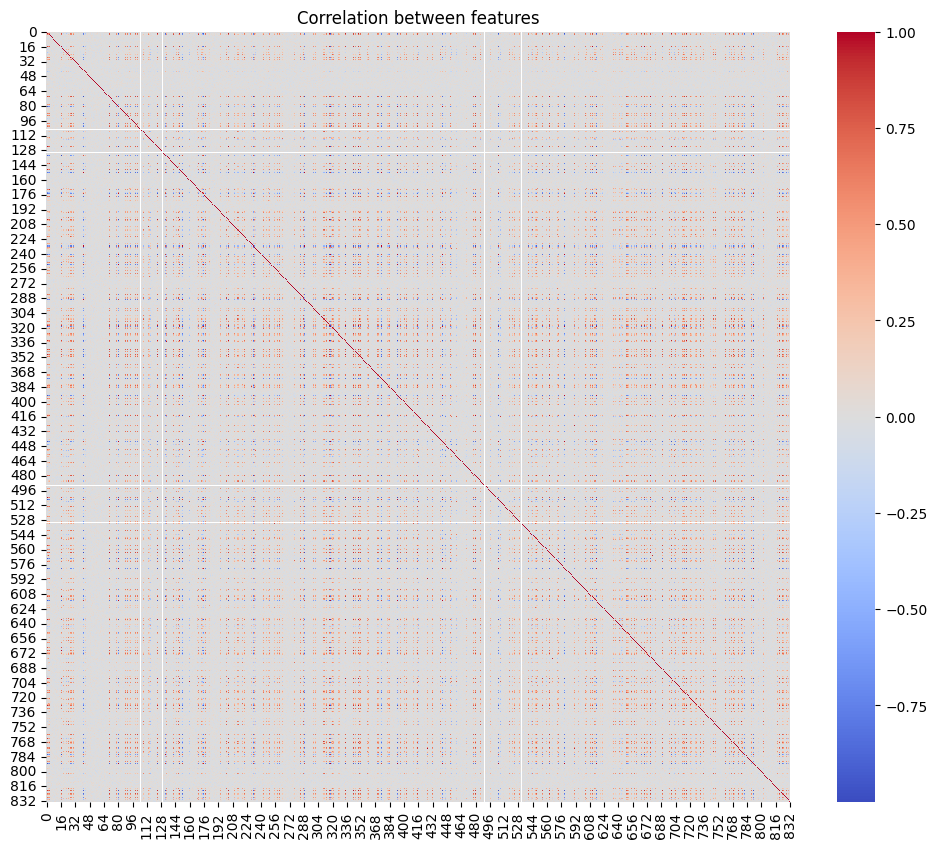

In [395]:
corr = X_train_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between features")
plt.show()

0      1212
704    1147
152    1146
729    1144
426    1144
       ... 
442    1131
407    1131
438    1131
315    1131
306    1131
Length: 100, dtype: int64


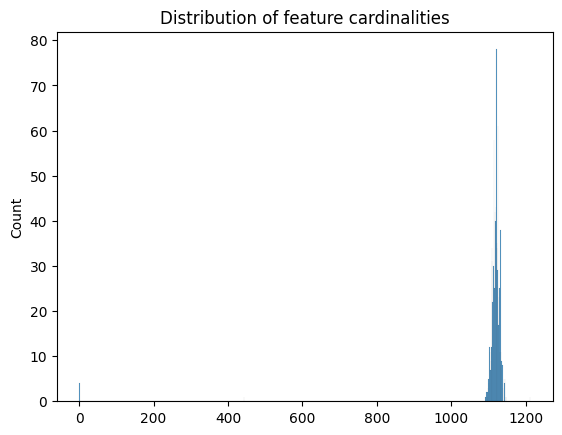

In [396]:
cardinalities = X_train_df.nunique().sort_values(ascending=False)
print(cardinalities.head(100))

sns.histplot(cardinalities, bins=1000)
plt.title("Distribution of feature cardinalities")
plt.show()

Features 105, 531, 130,105 have a cardinality of 1

In [397]:
z_scores = np.abs(stats.zscore(X_train_df.select_dtypes(include=np.number)))
outliers = (z_scores > 3).sum(axis=0)
print(outliers.shape)

(833,)


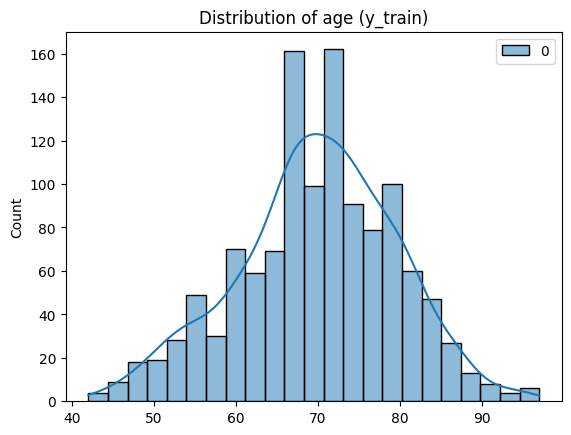

Skewness: [-0.20732709]
Kurtosis: [-0.10449548]


In [400]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

sns.histplot(y_train, kde=True)
plt.title("Distribution of age (y_train)")
plt.show()

print("Skewness:", skew(y_train))
print("Kurtosis:", kurtosis(y_train))
